In [1]:
from pathlib import Path
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
 
PROJECT_ROOT = Path("../..").resolve()
 
DATA_DIR = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / "hi" / "sol"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
summary = pd.read_csv(DATA_DIR / "protocol_summary_numeric.csv")
delta = pd.read_csv(DATA_DIR / "protocol_delta.csv")
folds = pd.read_csv(DATA_DIR / "protocol_per_fold.csv")
 
# Derived columns
summary["experiment_label"] = summary["model_short"] + " + " + summary["fingerprint"]
 
# Consistent style
PROTOCOL_COLORS = {
    "OOD holdout": "#2563EB",      # blue
    "Random shuffle": "#DC2626",   # red
}
 
MODEL_MARKERS = {
    "Decision Tree": "o",
    "Logistic Regression": "s",
    "Linear SVM": "^",
}

MODEL_SHORT_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
}

# Inner validation vs final OOD test (scatter)

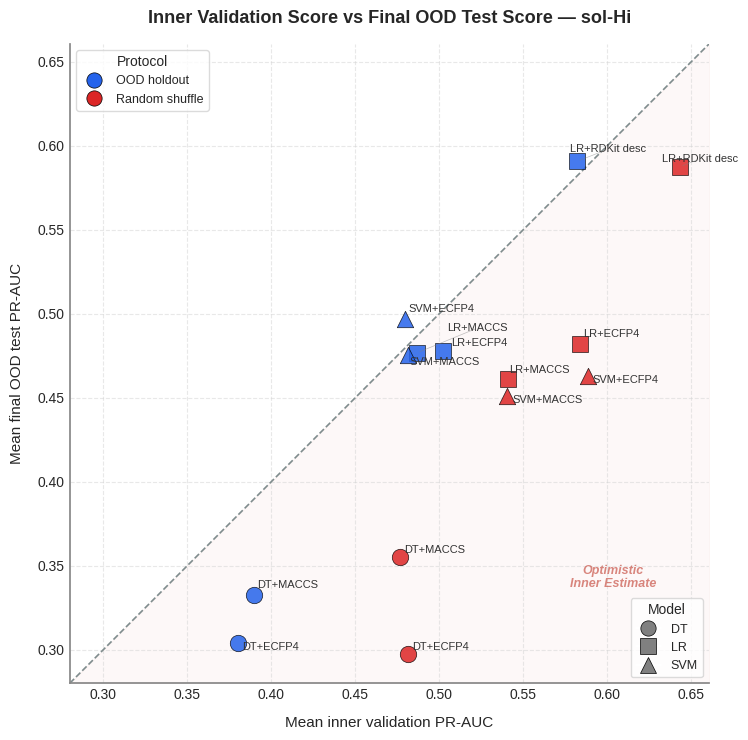

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text
import numpy as np 

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8.5, 7.5)) 

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', color='lightgrey', alpha=0.5, zorder=0)

min_val = min(summary["inner_mean"].min(), summary["test_mean"].min())
max_val = max(summary["inner_mean"].max(), summary["test_mean"].max())
padding = (max_val - min_val) * 0.05
lims = [min_val - padding, max_val + padding]

ax.plot(lims, lims, ls="--", lw=1.2, color="#7f8c8d", zorder=1) 

ax.fill_between(
    lims, lims, [lims[0], lims[0]],
    alpha=0.03, color="#c0392b", zorder=0, 
)

ax.text(
    0.85, 0.15, "Optimistic\nInner Estimate",
    transform=ax.transAxes, 
    fontsize=9, color="#c0392b", alpha=0.6, ha="center", weight='bold', style="italic",
)

for _, row in summary.iterrows():
    protocol = row["protocol"]
    model = row["model"]
    ax.scatter(
        row["inner_mean"],
        row["test_mean"],
        c=PROTOCOL_COLORS[protocol],
        marker=MODEL_MARKERS[model],
        s=140, 
        edgecolors="black", 
        alpha=0.85, 
        linewidths=0.5,
        zorder=3,
    )

texts = []
for _, row in summary.iterrows():
    label = f"{MODEL_SHORT_MAP[row['model']]}+{row['fingerprint']}"
    texts.append(
        ax.text(
            row["inner_mean"], 
            row["test_mean"], 
            label, 
            fontsize=8, 
            color='#333333'
        )
    )

adjust_text(
    texts, 
    ax=ax,
    arrowprops=dict(arrowstyle="-", color='grey', lw=0.5, alpha=0.5),
    expand_points=(1.2, 1.2)
)

protocol_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markersize=11, markeredgecolor='black', markeredgewidth=0.5, label=p)
    for p, c in PROTOCOL_COLORS.items()
]
model_handles = [
    Line2D([0], [0], marker=m, color="w", markerfacecolor="grey",
           markersize=11, markeredgecolor='black', markeredgewidth=0.5, label=MODEL_SHORT_MAP[name])
    for name, m in MODEL_MARKERS.items()
]

leg1 = ax.legend(
    handles=protocol_handles, title="Protocol",
    loc="upper left", fontsize=9, title_fontsize=10, frameon=True, edgecolor='lightgrey'
)
ax.add_artist(leg1)
ax.legend(
    handles=model_handles, title="Model",
    loc="lower right", fontsize=9, title_fontsize=10, frameon=True, edgecolor='lightgrey'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

ax.set_xlabel("Mean inner validation PR-AUC", fontsize=11, weight='medium', labelpad=10)
ax.set_ylabel("Mean final OOD test PR-AUC", fontsize=11, weight='medium', labelpad=10)
ax.set_title("Inner Validation Score vs Final OOD Test Score — sol-Hi", fontsize=13, weight='bold', pad=15)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_inner_vs_test_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Test PR-AUC with inner score overlay

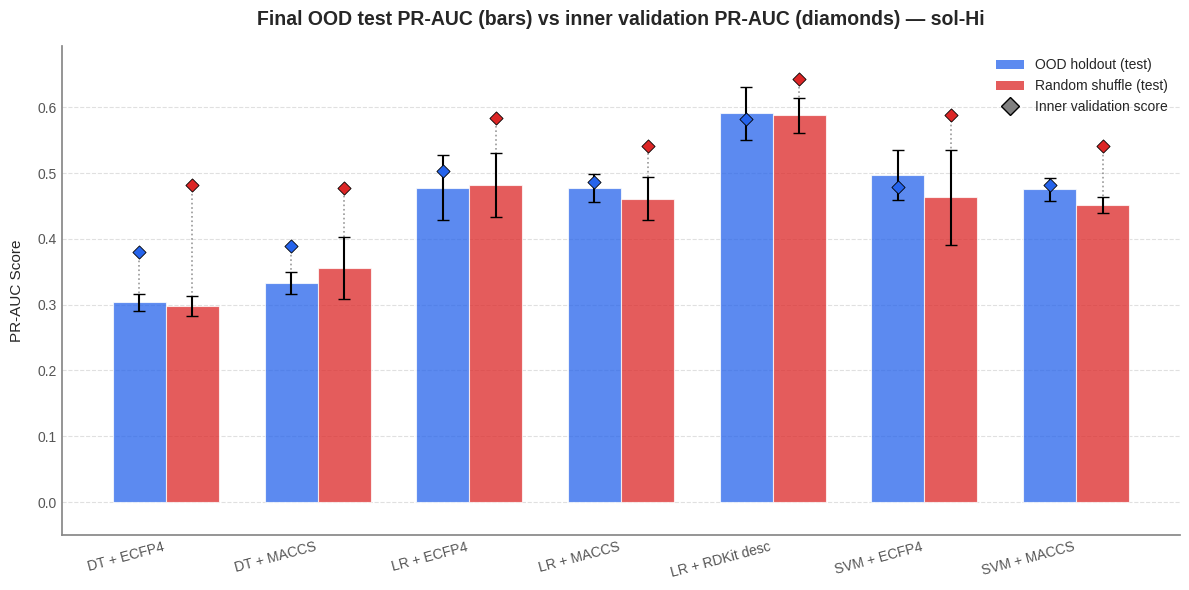

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

plot_df = summary.sort_values(["model_order", "fingerprint_order", "protocol_order"])
 
labels = plot_df["experiment_label"].drop_duplicates().tolist()
protocols = plot_df["protocol"].drop_duplicates().tolist()
 
x = np.arange(len(labels))
width = 0.35
 
fig, ax = plt.subplots(figsize=(12, 6))
 
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle='--', color='lightgrey', alpha=0.7, zorder=0)

for i, protocol in enumerate(protocols):
    sub = (
        plot_df[plot_df["protocol"] == protocol]
        .set_index("experiment_label")
        .reindex(labels)
        .reset_index()
    )
    offset = (i - 0.5) * width
    color = PROTOCOL_COLORS[protocol]
 
    bars = ax.bar(
        x + offset,
        sub["test_mean"],
        width,
        yerr=sub["test_std"],
        capsize=4,
        color=color,
        alpha=0.75,
        label=f"{protocol} — test",
        edgecolor="white",
        linewidth=0.8,
        zorder=3
    )
 
    ax.scatter(
        x + offset,
        sub["inner_mean"],
        marker="D",
        s=45,
        color=color,
        edgecolors="black",
        linewidths=0.6,
        zorder=4,
    )
 
    for j in range(len(sub)):
        test_val = sub.iloc[j]["test_mean"]
        inner_val = sub.iloc[j]["inner_mean"]
        ax.plot(
            [x[j] + offset, x[j] + offset],
            [test_val, inner_val],
            color="#555555",
            linewidth=1.2,
            alpha=0.6,
            linestyle=":",
            zorder=3
        )
 
bar_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=PROTOCOL_COLORS[p], alpha=0.75)
    for p in protocols
]
diamond_handle = Line2D(
    [0], [0], marker="D", color="w", markerfacecolor="grey",
    markeredgecolor="black", markersize=9, label="Inner validation score",
)
 
ax.legend(
    bar_handles + [diamond_handle],
    [f"{p} (test)" for p in protocols] + ["Inner validation score"],
    fontsize=10,
    loc="upper right",
    frameon=False
)
 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')
ax.tick_params(colors='#555555')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=15, ha='right')
ax.set_ylabel("PR-AUC Score", fontsize=11, weight='medium', labelpad=10)

ax.set_title(
    "Final OOD test PR-AUC (bars) vs inner validation PR-AUC (diamonds) — sol-Hi",
    fontsize=14,
    fontweight="bold",
    pad=15
)

max_val = max(summary["inner_mean"].max(), summary["test_mean"].max()) + 0.05
bottom_lim = ax.get_ylim()[0]
ax.set_ylim(bottom=bottom_lim - 0.05, top=max_val)


plt.tight_layout()
plt.savefig(FIG_DIR / "02_test_and_inner_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Fold-wise inner-test gap

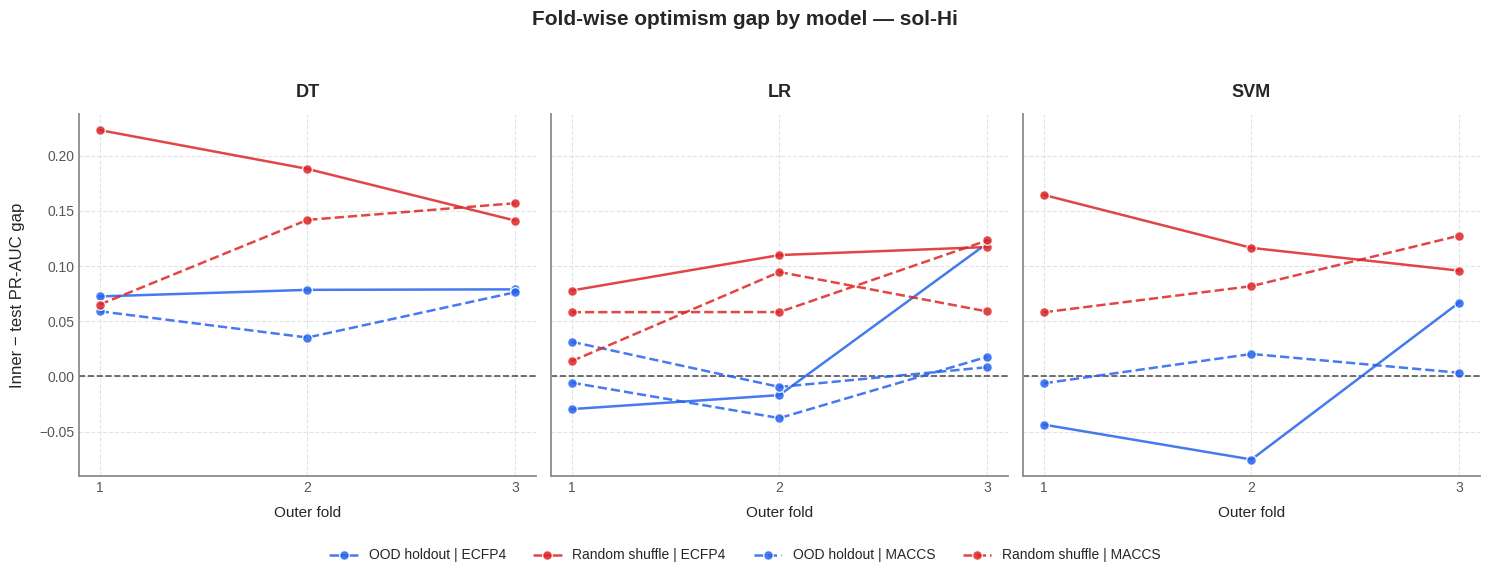

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

folds_plot = folds.copy()
folds_plot["line_label"] = folds_plot["protocol"] + " | " + folds_plot["fingerprint"]
folds_plot = folds_plot.sort_values(
    ["model_order", "fingerprint_order", "protocol_order", "fold"]
)
 
models = folds_plot["model"].drop_duplicates().tolist()
n_models = len(models)
 
fig, axes = plt.subplots(1, n_models, figsize=(15, 5), sharey=True)
 
if n_models == 1:
    axes = [axes]
 
for ax, model in zip(axes, models):
    sub_model = folds_plot[folds_plot["model"] == model]
 
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.6, zorder=0)
    ax.axhline(0, linewidth=1.2, color="#555555", linestyle="--", zorder=1)

    for line_label in sub_model["line_label"].drop_duplicates():
        sub = sub_model[sub_model["line_label"] == line_label].sort_values("fold")
 
        protocol = sub.iloc[0]["protocol"]
        fp = sub.iloc[0]["fingerprint"]
 
        color = PROTOCOL_COLORS[protocol]
        ls = "-" if fp == "ECFP4" else "--"
 
        ax.plot(
            sub["fold"],
            sub["inner_test_gap"],
            marker="o",
            color=color,
            linestyle=ls,
            linewidth=1.8,
            markersize=7,
            markeredgecolor='white',
            markeredgewidth=1,
            alpha=0.85,
            zorder=3,
            label=f"{protocol} | {fp}"
        )
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    ax.tick_params(colors='#555555')

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel("Outer fold", fontsize=11, weight='medium', labelpad=8)
    ax.set_title(MODEL_SHORT_MAP.get(model, model), fontsize=13, fontweight="bold", pad=12)
 
axes[0].set_ylabel("Inner − test PR-AUC gap", fontsize=12, weight='medium', labelpad=10)
 
handles, labels_leg = axes[-1].get_legend_handles_labels()
fig.legend(
    handles, labels_leg,
    loc="lower center",
    ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.08),
    frameon=False
)
 
fig.suptitle(
    "Fold-wise optimism gap by model — sol-Hi",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
 
plt.subplots_adjust(wspace=0.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_foldwise_gap_panel.png", dpi=300, bbox_inches="tight")
plt.show()

# Delta heatmap

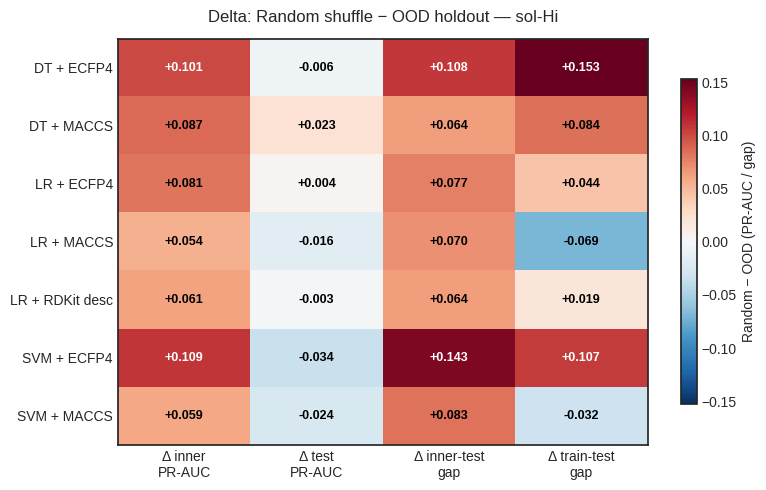

In [6]:
delta_plot = delta.copy()
delta_plot["experiment_label"] = delta_plot["model_short"] + " + " + delta_plot["fingerprint"]
delta_plot = delta_plot.sort_values(["model_order", "fingerprint_order"])
 
metrics = [
    "delta_inner",
    "delta_test",
    "delta_inner_test_gap",
    "delta_train_test_gap",
]
 
metric_labels = {
    "delta_inner": "Δ inner\nPR-AUC",
    "delta_test": "Δ test\nPR-AUC",
    "delta_inner_test_gap": "Δ inner-test\ngap",
    "delta_train_test_gap": "Δ train-test\ngap",
}
 
heatmap_df = delta_plot.set_index("experiment_label")[metrics]
 
# Diverging norm centered at zero
all_vals = heatmap_df.values.flatten()
vmax = max(abs(all_vals.min()), abs(all_vals.max()))
 
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
 
fig, ax = plt.subplots(figsize=(8, 5))
 
im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
)
 
ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(
    [metric_labels[m] for m in metrics],
    fontsize=10,
)
 
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=10)
 
# Annotate cells
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        text_color = "white" if abs(value) > vmax * 0.6 else "black"
        ax.text(
            j, i,
            f"{value:+.3f}",
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color=text_color,
        )
 
ax.set_title(
    "Delta: Random shuffle − OOD holdout — sol-Hi",
    fontsize=12,
    pad=12,
)
 
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Random − OOD (PR-AUC / gap)", fontsize=10)
 
plt.tight_layout()
plt.savefig(FIG_DIR / "04_delta_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()